## Project in Machine Learning - Shirel Amar 207065103 Sarah Derhy 340889435

In [1]:
import pandas as pd
import numpy as np
import os
import re
import requests
import time
import py7zr
import pycountry
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, GridSearchCV, cross_val_predict
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from functools import lru_cache
import joblib

# Download, unzip and read the file from GitHub

In [2]:
url = "https://raw.githubusercontent.com/SarahDerhy/Machine-Learning/main/dataset.7z"

response = requests.get(url, timeout=120)
response.raise_for_status()

with open("dataset.7z", "wb") as file:
    file.write(response.content)

os.makedirs("data", exist_ok=True)


with py7zr.SevenZipFile("dataset.7z", mode="r") as archive:
    archive.extractall(path="data")


df = pd.read_csv("data/dataset.csv", low_memory=False)

# Few test to understand the data

In [3]:
print(df.shape)

(133884, 13)


In [4]:
print(df.columns.tolist())

['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids', 'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes', 'budget', 'BoxOffice', 'plot']


In [5]:
df.describe()

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice
count,133884.000000,133884.000000,115560.000000,1.247620e+05,1.791600e+04
mean,1995.638792,97.235009,6.070235,7.562008e+03,4.705076e+07
std,64.751662,22.924321,1.292801,5.483444e+04,2.894113e+09
min,0.000000,60.000000,1.000000,0.000000e+00,0.000000e+00
25%,1982.000000,84.000000,5.300000,3.600000e+01,1.000000e+00
50%,2007.000000,93.000000,6.200000,1.730000e+02,7.900000e+00
75%,2017.000000,106.000000,7.000000,8.790000e+02,6.094750e+01
max,2026.000000,300.000000,10.000000,3.186698e+06,3.120000e+11


In [6]:
(df.isnull().mean() * 100).sort_values(ascending=False)

budget             87.638553
BoxOffice          86.618267
Country            59.904843
Language           58.380389
plot               55.432315
averageRating      13.686475
lead_actors_ids     7.491560
numVotes            6.813361
genres              1.921813
tconst              0.000000
primaryTitle        0.000000
startYear           0.000000
runtimeMinutes      0.000000
dtype: float64

# Checking the unusual value:

In [7]:

print((df["startYear"] == 0).sum()) #How many startyear value are 0
print(df["tconst"].duplicated().sum()) #Number of tconst that are duplicated
print(df["genres"].dropna().head(20).tolist()) #List of first non null 20 values in genre column
print(df["genres"].value_counts(dropna=False).head(20)) #Displays the 20 most frequent values in genres column and number value appears.

print(df["Country"].dropna().head(20).tolist()) #List of first non null 20 values in country column
print(df["Country"].value_counts(dropna=False).head(20)) #Displays the 20 most frequent values in country column and number value appears.
print(df["Language"].dropna().head(20).tolist()) #List of first non null 20 values in language column
print(df["Language"].value_counts(dropna=False).head(20)) #Displays the 20 most frequent values in language column and number value appears.
print(df["lead_actors_ids"].dropna().head(20).tolist())  #List of first non null 20 values in lead actors ids column
print(df["plot"].dropna().head(10).tolist())  #List of first non null 10 values in plot column

120
0
['Crime,Drama,Thriller', 'Drama', 'Drama,Romance', 'Documentary', 'Comedy', 'Comedy', 'Biography,Documentary,Music', 'Documentary', 'Adventure,Animation,Documentary', 'Comedy', 'Drama', 'Romance', 'Biography,Comedy,Music', 'Comedy,Crime,Drama', 'Comedy', 'Drama', 'Comedy,Romance', 'Adventure', 'Drama,Thriller', 'Adult,Comedy']
genres
Drama                             10822
['Drama']                         10224
Documentary                        6074
['Documentary']                    5542
Comedy                             5338
['Comedy']                         4539
NaN                                2573
Comedy,Drama                       2438
Drama,Romance                      2326
[]                                 2065
['Comedy', 'Drama']                1906
['Drama', 'Romance']               1860
Horror                             1540
Comedy,Romance                     1487
Comedy,Drama,Romance               1374
['Comedy', 'Romance']              1092
['Horror']        

In [8]:
print("\nMost frequent budget values:")
print(df["budget"].value_counts(dropna=False).head(20))

print("\nExamples of non-null budget values:")
print(df["budget"].dropna().head(30).tolist())


Most frequent budget values:
budget
NaN     117334
20.0       191
10.0       187
25.0       178
5.0        169
1.5        164
3.0        156
15.0       152
1.0        152
30.0       149
2.0        135
2.5        132
4.0        122
6.0        118
0.0        116
40.0       113
12.0       110
0.5        110
35.0       110
3.5        106
Name: count, dtype: int64

Examples of non-null budget values:
['$5 million', '₹25  crore', '₹55 crore', '$458,000', '$15 million', '₹5–8 crore', 'est. ₹80 crore', '$55 million', 'est.\u2009₹1.5 crore (US$160,000)', 'A$2.5 million', '$400,000 (Estimated)', '$3,200,000', '£85,785', '$2,000,000 (estimated)', '$25 million', '$28 million', '$26 million', '₹40 crore', '$75,000', '$4.5 million', '$21 million', '$199,000', '$10–12 million', '$432,000', '$5 million', '$1 million', '₹7.8 crore', '$21 million', '1.8 million', '₹7.75 crore']


# Finding the most frequent genres in the dataset for the prepare Data function

In [9]:

genres_clean = (
    df["genres"]
    .fillna("")
    .astype(str)
    .str.replace(r"[\[\]'\"]", "", regex=True)
    .str.replace(r"\s*,\s*", ",", regex=True)
    .str.strip()
)

genre_counts = (
    genres_clean
    .str.get_dummies(sep=",")
    .sum()
    .sort_values(ascending=False)
)

print(genre_counts.head(20))

Drama          64056
Comedy         35201
Documentary    18264
Romance        16584
Action         14862
Crime          13017
Thriller       12296
Horror         10371
Adventure       8657
Mystery         5874
Family          5332
Biography       4641
Fantasy         4414
Music           3765
History         3757
Sci-Fi          3522
Musical         2839
War             2741
Animation       2612
Sport           1794
dtype: int64


# Load IMDb crew data only once:

In [10]:
@lru_cache(maxsize=1)
def load_crew():
    crew = pd.read_csv(
        "https://datasets.imdbws.com/title.crew.tsv.gz",
        sep="\t",
        compression="gzip",
        usecols=["tconst", "directors"],
        low_memory=False
    )

    return crew.replace("\\N", pd.NA)



# Helper function : Create the country recognition pattern

In [11]:
@lru_cache(maxsize=1)
def build_country_pattern():
    country_names = [country.name for country in pycountry.countries]

    country_names += [
        "USA",
        "UK",
        "United States",
        "United States of America",
        "England",
        "Britain",
        "Great Britain",
        "East Germany",
        "West Germany",
        "Czechoslovakia",
        "Soviet Union",
        "Yugoslavia"
    ]

    return "|".join(
        sorted(map(re.escape, country_names), key=len, reverse=True)
    )




# Fixed list based on the most frequent genres in the training dataset

In [12]:
main_genres = ["Drama","Comedy","Documentary","Romance","Action","Crime","Thriller","Horror","Adventure","Mystery"]

# Prepare_data function:
- Cleaning columns
- Create features
- Drop features we don't need for models


In [13]:
def prepare_data(df):
    df = df.copy()

    # Load crew file and merge it with df:
    crew = load_crew()
    country_pattern = build_country_pattern()


    df = df.merge(crew[["tconst", "directors"]],on="tconst", how="left")

    df["directors_list"] = df["directors"].str.split(",")

    # Count directors for each movie
    df["num_directors"] = (pd.to_numeric(df["directors_list"].str.len(), errors="coerce").fillna(0).astype(int))

   

    df["genres"] = (df["genres"].fillna("").astype(str).str.replace(r"[\[\]'\"]", "", regex=True)
                        .str.replace(r"\s*,\s*", ",", regex=True)
                        .str.strip()
                        .replace("", np.nan))

    # Create one binary column for each frequent genre
    genre_dummies = (df["genres"].fillna("").str.get_dummies(sep=","))

    main_genre_dummies = (genre_dummies.reindex(columns=main_genres, fill_value=0).add_prefix("genre_"))

    df = pd.concat([df, main_genre_dummies], axis=1)

    # 1 if the movie contains at least one less frequent genre
    rare_genres = genre_dummies.columns.difference(main_genres)

    df["genre_Other"] = (genre_dummies[rare_genres].any(axis=1).astype(int))

    
    
    df["Country"] = (df["Country"].replace("Not Found", np.nan).astype("string").str.strip()
                        .str.replace(r"\[\s*\d+\s*\]", "", regex=True)
                        .str.extract(f"({country_pattern})", expand=False)
                        .str.strip())

    # Normalize country variants
    country_lower = df["Country"].str.lower().str.strip()

    df["Country"] = df["Country"].mask(
        country_lower.isin(["usa","us","u.s.","u.s.a.","united states","united states of america"]),"USA")

    df["Country"] = df["Country"].mask(
        country_lower.isin(["uk","united kingdom","england","britain","great britain"]),"UK")

    # Create country groups
    country_lower = df["Country"].str.lower().str.strip()

    country_mapping = {
        "usa": "USA",
        "uk": "UK",
        "france": "France",
        "india": "India",
        "italy": "Italy",
        "japan": "Japan",
        "canada": "Canada"}

    df["country_group"] = country_lower.map(country_mapping)

    # Known countries outside the selected groups become Other
    df.loc[df["Country"].notna() & df["country_group"].isna(),"country_group"] = "Other"

    # Country-related features
    df["country_known"] = df["Country"].notna().astype(int)


    # Invalid or post-2025 release years become missing values
    df["startYear"] = pd.to_numeric(df["startYear"],errors="coerce")

    df["startYear"] = df["startYear"].where(df["startYear"].between(1, 2025),np.nan)

    # Decade as a categorical feature
    df["decade"] = (((df["startYear"] // 10) * 10).astype("Int64").astype("string") + "s").astype(object)

    # Number of genres
    df["num_genres"] = (df["genres"].str.split(",").str.len().fillna(0).astype(int))

    # Number of lead actors
    df["num_lead_actors"] = (df["lead_actors_ids"].fillna("").astype(str).str.count(r"nm\d+").astype(int))


    df["directors_x_genres"] = (df["num_directors"] * df["num_genres"])
    
    df["film_age"] = 2026 - df["startYear"]
    df["age_x_country_known"] = (df["film_age"] * df["country_known"])

    # Remove unused columns and leakage features
    df = df.drop(columns=[
        "averageRating",
        "numVotes",
        "BoxOffice",
        "tconst",
        "primaryTitle",
        "lead_actors_ids",
        "plot",
        "Language",
        "Country",
        "directors",
        "directors_list",
        "startYear",
        "budget",
        "film_age",
        "genres"
    ], errors="ignore")
    
    # Convert categorical missing values to np.nan for sklearn compatibility
    categorical_cols = ["country_group", "decade"]

    df[categorical_cols] = (
        df[categorical_cols]
        .astype(object)
        .where(df[categorical_cols].notna(), np.nan)
    )

    return df 

# Created features:
- num_directors          : number of directors for the movie
- genre_<name>           : binary columns for the most frequent genres
- genre_Other            : 1 if the movie contains at least one less frequent genre
- country_group          : grouped country category
- country_known          : 1 if country information is available, 0 otherwise
- decade                 : release decade of the movie
- num_genres             : number of genres associated with the movie
- num_lead_actors        : number of lead actors
- directors_x_genres     : interaction between number of directors and number of genres
- age_x_country_known    : interaction between movie age and country availability

# Separate features into numerical and categorical features for the Pipeline

In [14]:
genre_features = [f"genre_{genre}" for genre in main_genres] + ["genre_Other"]

numeric_features = ["runtimeMinutes","num_directors","country_known","num_genres","num_lead_actors",
                    "directors_x_genres",
                    "age_x_country_known"] + genre_features 

categorical_features = ["country_group","decade"]

# Pipeline

In [15]:
# Numeric pipelime
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# Categorial pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

# Preprocessor

In [16]:
preprocessor = ColumnTransformer([("num", numeric_transformer, numeric_features),
                                ("cat", categorical_transformer, categorical_features)])

# Defining X and y variables

In [17]:
df_clean = df[df["averageRating"].notna()].copy()
y = df_clean["averageRating"]
X = prepare_data(df_clean)


print(X.columns)

Index(['runtimeMinutes', 'num_directors', 'genre_Drama', 'genre_Comedy',
       'genre_Documentary', 'genre_Romance', 'genre_Action', 'genre_Crime',
       'genre_Thriller', 'genre_Horror', 'genre_Adventure', 'genre_Mystery',
       'genre_Other', 'country_group', 'country_known', 'decade', 'num_genres',
       'num_lead_actors', 'directors_x_genres', 'age_x_country_known'],
      dtype='object')


In [18]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (115560, 20)
Shape y: (115560,)


In [19]:
print(X.isna().sum())

runtimeMinutes             0
num_directors              0
genre_Drama                0
genre_Comedy               0
genre_Documentary          0
genre_Romance              0
genre_Action               0
genre_Crime                0
genre_Thriller             0
genre_Horror               0
genre_Adventure            0
genre_Mystery              0
genre_Other                0
country_group          66944
country_known              0
decade                    38
num_genres                 0
num_lead_actors            0
directors_x_genres         0
age_x_country_known       38
dtype: int64


# Checking the preprocessor is working

In [20]:
X_transformed = preprocessor.fit_transform(X)

print(X_transformed.shape)

(115560, 39)


In [21]:
X.describe()

,runtimeMinutes,num_directors,genre_Drama,genre_Comedy,genre_Documentary,genre_Romance,genre_Action,genre_Crime,genre_Thriller,genre_Horror,genre_Adventure,genre_Mystery,genre_Other,country_known,num_genres,num_lead_actors,directors_x_genres,age_x_country_known
count,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115560.000000,115522.000000
mean,98.573183,1.125701,0.505884,0.288300,0.112617,0.135800,0.121037,0.107355,0.101636,0.086509,0.071296,0.048226,0.267160,0.420699,1.887989,4.197421,2.123892,14.191877
std,22.346947,0.685347,0.499968,0.452974,0.316125,0.342577,0.326171,0.309566,0.302170,0.281116,0.257320,0.214244,0.442478,0.493673,0.852281,1.664133,1.696616,24.331414
min,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,85.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.000000,1.000000,0.000000
50%,94.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,5.000000,2.000000,0.000000
75%,107.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,5.000000,3.000000,18.000000
max,300.000000,58.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,5.000000,123.000000,116.000000


# Building models:

### Model 1 — Elastic Net
- Linear regression with L1 and L2 regularization.
- Alpha controls penalty strength.
- l1_ratio controls the balance between Lasso and Ridge.

In [22]:
model_elastic = Pipeline([("preprocessor", preprocessor),
                        ("all_features_scaler", StandardScaler(with_mean=False)),
                        ("model", ElasticNet(random_state=42))])

# Hyperparameter tuning 
param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}


grid_search = GridSearchCV(
    estimator=model_elastic,
    param_grid=param_grid,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X, y)

print(f"Best alpha   : {grid_search.best_params_['model__alpha']}")
print(f"Best l1_ratio: {grid_search.best_params_['model__l1_ratio']}")
print(f"Best RMSE: {-grid_search.best_score_:.3f}")

# Keep the best tuned model
model_elastic = grid_search.best_estimator_

Best alpha   : 0.01
Best l1_ratio: 0.1
Best RMSE: 1.137


## Model 2 — Random Forest
- model__n_estimators : Number of trees in the forest. More trees improve stability.
- model__max_depth : Maximum depth of each tree. Larger the depth  more complex the patterns is.
- model__min_samples_leaf : Minimum number of samples required in each final leaf. Larger values make the trees simpler and reduce overfitting.

In [23]:
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_jobs=1,  
        random_state=42
    ))
])

# Hyperparameter tuning
param_grid_rf = {
    "model__n_estimators": [50, 100, 200], 
    "model__max_depth": [5, 10, 20], 
    "model__min_samples_leaf": [2, 5, 10] 
}

grid_search_rf = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid_rf,
    cv=10,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X, y)

print(f"Best n_estimators     : {grid_search_rf.best_params_['model__n_estimators']}")
print(f"Best max_depth        : {grid_search_rf.best_params_['model__max_depth']}")
print(f"Best min_samples_leaf : {grid_search_rf.best_params_['model__min_samples_leaf']}")
print(f"Best RMSE             : {-grid_search_rf.best_score_:.3f}")

# Keep the best tuned model
model_rf = grid_search_rf.best_estimator_

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Best n_estimators     : 200
Best max_depth        : 20
Best min_samples_leaf : 10
Best RMSE             : 1.114


# Testing models

## Elastic Net:

In [24]:
scoring = ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"]


results_elastic = cross_validate(model_elastic, X, y, cv=10, scoring=scoring)

print("=== ELASTIC NET ===")
print(f"RMSE : {-results_elastic['test_neg_root_mean_squared_error'].mean():.3f} ± {results_elastic['test_neg_root_mean_squared_error'].std():.3f}")
print(f"MAE  : {-results_elastic['test_neg_mean_absolute_error'].mean():.3f} ± {results_elastic['test_neg_mean_absolute_error'].std():.3f}")
print(f"R²   : {results_elastic['test_r2'].mean():.3f} ± {results_elastic['test_r2'].std():.3f}")



=== ELASTIC NET ===
RMSE : 1.137 ± 0.047
MAE  : 0.873 ± 0.036
R²   : 0.222 ± 0.021


## Random Forest: 

In [25]:
results_rf = cross_validate(model_rf, X, y, cv=10, scoring=scoring)
print("\n=== RANDOM FOREST ===")
print(f"RMSE : {-results_rf['test_neg_root_mean_squared_error'].mean():.3f} ± {results_rf['test_neg_root_mean_squared_error'].std():.3f}")
print(f"MAE  : {-results_rf['test_neg_mean_absolute_error'].mean():.3f} ± {results_rf['test_neg_mean_absolute_error'].std():.3f}")
print(f"R²   : {results_rf['test_r2'].mean():.3f} ± {results_rf['test_r2'].std():.3f}")



=== RANDOM FOREST ===
RMSE : 1.114 ± 0.052
MAE  : 0.849 ± 0.040
R²   : 0.254 ± 0.027


## Compare models using lowest cross-validation mean RMSE

In [26]:
rmse_elastic = -results_elastic["test_neg_root_mean_squared_error"].mean()
rmse_rf = -results_rf["test_neg_root_mean_squared_error"].mean()

print(f"Elastic Net RMSE  : {rmse_elastic:.3f}")
print(f"Random Forest RMSE: {rmse_rf:.3f}")


if rmse_rf < rmse_elastic:
    best_model = model_rf
    best_model_name = "Random Forest"
else:
    best_model = model_elastic
    best_model_name = "Elastic Net"

print(f"\nBest model: {best_model_name}")

Elastic Net RMSE  : 1.137
Random Forest RMSE: 1.114

Best model: Random Forest


# 5.1 Extract outliers from cross-validation predictions
- Reset index to keep rows aligned with predictions
- Recreate target and features after resetting the index
- Get one out-of-fold prediction for each movie
- Build a dataframe with prediction errors
- Choosing 10 lowest and highest prediction

In [27]:
df_clean = df_clean.reset_index(drop=True)

y = df_clean["averageRating"]
X = prepare_data(df_clean)


y_pred = cross_val_predict(best_model, X, y, cv=10)


errors = pd.DataFrame({
    "tconst":       df_clean["tconst"],
    "primaryTitle": df_clean["primaryTitle"],
    "startYear":    df_clean["startYear"],
    "genres":       df_clean["genres"],
    "y_true":       y.values,
    "y_pred":       y_pred,
    "error":        y_pred - y.values
})

top_over = errors.nlargest(10, "error")

top_under = errors.nsmallest(10, "error")

In [28]:
top_over[["tconst", "primaryTitle", "startYear", "genres", "y_true", "y_pred", "error"]]

,tconst,primaryTitle,startYear,genres,y_true,y_pred,error
72407,tt26734133,Zoo School,2019.0,['Animation'],1.1,7.259242,6.159242
8633,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",1.0,7.120487,6.120487
115239,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",1.0,7.008621,6.008621
12414,tt28870073,Kurz,2023.0,Documentary,1.2,7.205634,6.005634
60471,tt6748034,Tribalism Is Killing Us,2019.0,['Documentary'],1.3,7.252007,5.952007
43217,tt0808438,Rape of the Soul,2006.0,"['Documentary', 'History']",1.7,7.576530,5.876530
72305,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],1.2,7.014613,5.814613
7332,tt5355524,Jasenovac: Istina,2016.0,"Documentary,History,Mystery",1.4,7.212536,5.812536
43273,tt2124890,Ramo Trip,2012.0,['Documentary'],1.4,7.164444,5.764444
81148,tt11536660,At the Back of the Screen,2020.0,"Documentary,Drama",1.5,7.221730,5.721730


In [29]:
top_under[["tconst", "primaryTitle", "startYear", "genres", "y_true", "y_pred", "error"]]

,tconst,primaryTitle,startYear,genres,y_true,y_pred,error
88952,tt2379727,Bukunja Tekunja Mitti: The Cannibals,2012.0,"['Action', 'Horror']",9.1,4.039670,-5.060330
47979,tt1684589,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,"Horror,Thriller",9.1,4.300941,-4.799059
5802,tt12958602,Il Santo Veleno,2023.0,Thriller,9.4,4.604942,-4.795058
66984,tt4267586,Ungleich,2013.0,"['Fantasy', 'Horror']",9.1,4.350349,-4.749651
66517,tt39000499,Under Reflex,2024.0,"['Action', 'Comedy', 'Drama']",9.4,4.661507,-4.738493
113055,tt33461129,Halloween Deluxe,2019.0,Horror,9.1,4.473223,-4.626777
34473,tt2166087,Pulse of the Indigo,2012.0,"Crime,Thriller",9.3,4.678914,-4.621086
29350,tt6039316,Oscuro by Rene Potter,2016.0,['Horror'],8.6,4.025505,-4.574495
34089,tt16436030,Puli Vachindi Meka Chachindi,2021.0,Thriller,9.5,5.044125,-4.455875
756,tt31842614,Ice Nine Kills Presents: Welcome to Horrorwood,2024.0,Horror,8.4,3.965750,-4.434250


# 5.2 Qualitative analysis of the 20 outliers:
- Merge the 10 largest overpredictions and underpredictions
- Add useful engineered features for the analysis
- Display the complete table of 20 outliers

In [30]:
outliers_20 = pd.concat([
    top_over.assign(error_type="Overprediction"),
    top_under.assign(error_type="Underprediction")
])


outliers_20 = outliers_20.join(
    X[[
        "country_group",
        "decade",
        "num_genres",
        "num_directors",
        "num_lead_actors",
        "country_known"
    ]]
)


outliers_20[["error_type","tconst","primaryTitle","startYear","genres","country_group","decade","num_genres","num_directors","num_lead_actors",
                "y_true",
                "y_pred",
                "error"]]



,error_type,tconst,primaryTitle,startYear,genres,country_group,decade,num_genres,num_directors,num_lead_actors,y_true,y_pred,error
72407,Overprediction,tt26734133,Zoo School,2019.0,['Animation'],NaN,2010s,1,1,0,1.1,7.259242,6.159242
8633,Overprediction,tt3059576,Justin Bieber: Always Believing,2012.0,"Documentary,Music",NaN,2010s,2,1,1,1.0,7.120487,6.120487
115239,Overprediction,tt13452818,Horseplay: The History of Horse Riding,2021.0,"Animation,Documentary",NaN,2020s,2,1,0,1.0,7.008621,6.008621
12414,Overprediction,tt28870073,Kurz,2023.0,Documentary,NaN,2020s,1,1,0,1.2,7.205634,6.005634
60471,Overprediction,tt6748034,Tribalism Is Killing Us,2019.0,['Documentary'],NaN,2010s,1,1,0,1.3,7.252007,5.952007
43217,Overprediction,tt0808438,Rape of the Soul,2006.0,"['Documentary', 'History']",NaN,2000s,2,1,1,1.7,7.576530,5.876530
72305,Overprediction,tt0498734,Zwischen Glück und Krone,1959.0,['Documentary'],NaN,1950s,1,1,0,1.2,7.014613,5.814613
7332,Overprediction,tt5355524,Jasenovac: Istina,2016.0,"Documentary,History,Mystery",NaN,2010s,3,1,2,1.4,7.212536,5.812536
43273,Overprediction,tt2124890,Ramo Trip,2012.0,['Documentary'],NaN,2010s,1,4,5,1.4,7.164444,5.764444
81148,Overprediction,tt11536660,At the Back of the Screen,2020.0,"Documentary,Drama",USA,2020s,2,1,5,1.5,7.221730,5.721730


## Compare the average numerical characteristics of both groups

In [31]:
outliers_20.groupby("error_type")[
    [
        "startYear",
        "num_genres",
        "num_directors",
        "num_lead_actors",
        "country_known",
        "y_true",
        "y_pred",
        "error"
    ]
].mean()

,startYear,num_genres,num_directors,num_lead_actors,country_known,y_true,y_pred,error
error_type,,,,,,,,
Overprediction,2010.7,1.6,1.3,1.4,0.1,1.28,7.203584,5.923584
Underprediction,2017.5,1.6,1.4,4.2,0.0,9.10,4.414493,-4.685507


## Count outliers by decade

In [32]:
outliers_20.groupby(["error_type", "decade"]).size().unstack(fill_value=0)

decade,1950s,2000s,2010s,2020s
error_type,,,,
Overprediction,1,1,5,3
Underprediction,0,0,6,4


## Count outliers by country group

In [33]:
outliers_20.groupby(["error_type", "country_group"]).size().unstack(fill_value=0)

country_group,USA
error_type,
Overprediction,1


## Compare genres between overpredictions and underpredictions

In [34]:
genre_columns = [col for col in X.columns if col.startswith("genre_")]

outliers_with_genres = outliers_20.join(X[genre_columns])

outliers_with_genres.groupby("error_type")[genre_columns].sum().T

error_type,Overprediction,Underprediction
genre_Drama,1,1
genre_Comedy,0,1
genre_Documentary,9,0
genre_Romance,0,0
genre_Action,0,2
genre_Crime,0,1
genre_Thriller,0,4
genre_Horror,0,6
genre_Adventure,0,0
genre_Mystery,1,0


# OVERPREDICTION:
- Overpredictions mainly concern documentaries: 9 out of 10 films belong to the Documentary genre.
- These films received very low actual ratings, while the model predicted much higher scores. Most of them are also recent: 8 out of 10 were released in the 2010s or 2020s. 
This suggests that the model struggles to distinguish poorly received recent documentaries from documentaries that usually receive higher ratings.


# UNDERPREDICTIONS 
- Underpredictions mainly concern recent films: most were released in the 2010s or 2020s.
- Country information is missing for most of these movies, so no reliable country-related pattern can be identified.
- The underpredictions are mostly associated with Horror and Thriller films: 4 out of 10 belong to the Horror genre and 6 out of 10 belong to the Thriller genre.
These two genres are closely related, which suggests that the model tends to underestimate highly rated suspense or horror films.

# 5.3 Compare outliers from both models
- Build one dataframe containing errors from both models

In [35]:
y_pred_rf = cross_val_predict(model_rf, X, y, cv=10)

y_pred_elastic = cross_val_predict(model_elastic, X, y, cv=10)


errors_comparison = pd.DataFrame({"tconst": df_clean["tconst"].values,
                                "primaryTitle": df_clean["primaryTitle"].values,
                                "genres": df_clean["genres"].values,
                                "y_true": y.values,
                                "y_pred_rf": y_pred_rf,
                                "y_pred_elastic": y_pred_elastic})

errors_comparison["error_rf"] = (errors_comparison["y_pred_rf"] - errors_comparison["y_true"])

errors_comparison["error_elastic"] = (errors_comparison["y_pred_elastic"] - errors_comparison["y_true"])

errors_comparison["abs_error_rf"] = (errors_comparison["error_rf"].abs())

errors_comparison["abs_error_elastic"] = (errors_comparison["error_elastic"].abs())




- Extract the 20 outliers for each model
- Display Random Forest outliers
- Display Elastic Net outliers


In [36]:
top_over_rf = errors_comparison.nlargest(10, "error_rf")
top_under_rf = errors_comparison.nsmallest(10, "error_rf")

top_over_elastic = errors_comparison.nlargest(10, "error_elastic")
top_under_elastic = errors_comparison.nsmallest(10, "error_elastic")

outliers_rf = pd.concat([top_over_rf.assign(error_type="Overprediction"),
                        top_under_rf.assign(error_type="Underprediction")])

outliers_elastic = pd.concat([top_over_elastic.assign(error_type="Overprediction"),
                            top_under_elastic.assign(error_type="Underprediction")])




display(outliers_rf[["error_type", "tconst", "primaryTitle", "genres", "y_true", "y_pred_rf", "error_rf"]])

display(outliers_elastic[["error_type","tconst","primaryTitle","genres","y_true","y_pred_elastic","error_elastic"]])




,error_type,tconst,primaryTitle,genres,y_true,y_pred_rf,error_rf
72407,Overprediction,tt26734133,Zoo School,['Animation'],1.1,7.259242,6.159242
8633,Overprediction,tt3059576,Justin Bieber: Always Believing,"Documentary,Music",1.0,7.120487,6.120487
115239,Overprediction,tt13452818,Horseplay: The History of Horse Riding,"Animation,Documentary",1.0,7.008621,6.008621
12414,Overprediction,tt28870073,Kurz,Documentary,1.2,7.205634,6.005634
60471,Overprediction,tt6748034,Tribalism Is Killing Us,['Documentary'],1.3,7.252007,5.952007
43217,Overprediction,tt0808438,Rape of the Soul,"['Documentary', 'History']",1.7,7.576530,5.876530
72305,Overprediction,tt0498734,Zwischen Glück und Krone,['Documentary'],1.2,7.014613,5.814613
7332,Overprediction,tt5355524,Jasenovac: Istina,"Documentary,History,Mystery",1.4,7.212536,5.812536
43273,Overprediction,tt2124890,Ramo Trip,['Documentary'],1.4,7.164444,5.764444
81148,Overprediction,tt11536660,At the Back of the Screen,"Documentary,Drama",1.5,7.221730,5.721730


,error_type,tconst,primaryTitle,genres,y_true,y_pred_elastic,error_elastic
81148,Overprediction,tt11536660,At the Back of the Screen,"Documentary,Drama",1.5,8.331347,6.831347
72305,Overprediction,tt0498734,Zwischen Glück und Krone,['Documentary'],1.2,7.476742,6.276742
43217,Overprediction,tt0808438,Rape of the Soul,"['Documentary', 'History']",1.7,7.734881,6.034881
60471,Overprediction,tt6748034,Tribalism Is Killing Us,['Documentary'],1.3,7.313328,6.013328
115239,Overprediction,tt13452818,Horseplay: The History of Horse Riding,"Animation,Documentary",1.0,6.923115,5.923115
12414,Overprediction,tt28870073,Kurz,Documentary,1.2,7.119733,5.919733
8633,Overprediction,tt3059576,Justin Bieber: Always Believing,"Documentary,Music",1.0,6.916697,5.916697
4190,Overprediction,tt0015939,Idaho,"Adventure,Drama,Western",1.9,7.777776,5.877776
30164,Overprediction,tt1615051,Obama in NC: The Path to History,['Documentary'],1.5,7.339894,5.839894
43273,Overprediction,tt2124890,Ramo Trip,['Documentary'],1.4,7.236454,5.836454


 ### Visual comparison of model errors on outliers

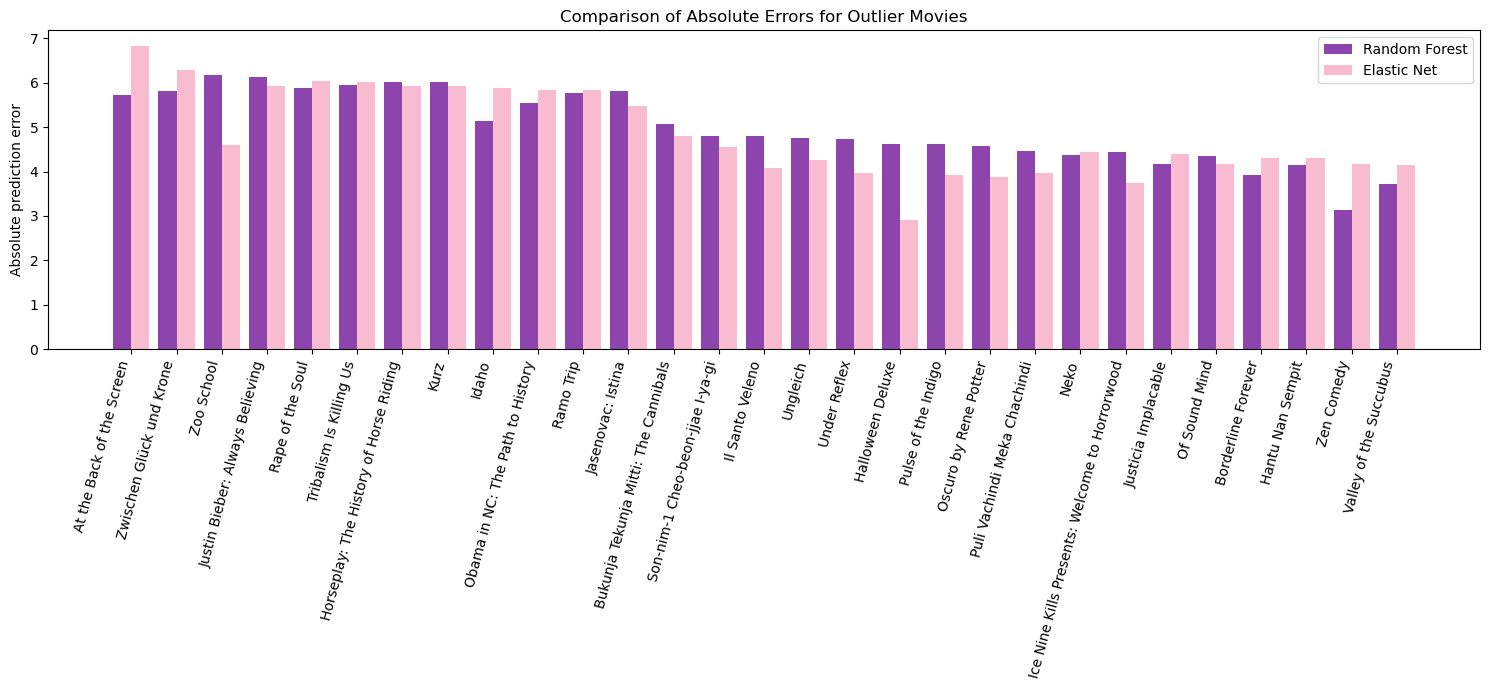

In [37]:
all_outlier_ids = set(outliers_rf["tconst"]) | set(outliers_elastic["tconst"])

plot_data = (errors_comparison[errors_comparison["tconst"].isin(all_outlier_ids)].copy())

plot_data["max_abs_error"] = (plot_data[["abs_error_rf", "abs_error_elastic"]].max(axis=1))

plot_data = (plot_data.sort_values("max_abs_error", ascending=False).reset_index(drop=True))

positions = np.arange(len(plot_data))
width = 0.4

fig, ax = plt.subplots(figsize=(15, 7))

ax.bar(positions - width / 2, plot_data["abs_error_rf"], width, label="Random Forest", color="#8E44AD")

ax.bar(positions + width / 2, plot_data["abs_error_elastic"], width, label="Elastic Net", color="#F8BBD0")

ax.set_xticks(positions)
ax.set_xticklabels(plot_data["primaryTitle"], rotation=75, ha="right")

ax.set_ylabel("Absolute prediction error")
ax.set_title("Comparison of Absolute Errors for Outlier Movies")
ax.legend()

plt.tight_layout()
plt.show()


## Count commons outliers

In [38]:
rf_ids = set(outliers_rf["tconst"])
elastic_ids = set(outliers_elastic["tconst"])

common_ids = rf_ids & elastic_ids

print("Number of common outliers:", len(common_ids), "/ 20")


Number of common outliers: 11 / 20


## Compare both models on all films identified as outliers by at least one of the models

In [39]:
all_outlier_ids = rf_ids | elastic_ids

outlier_comparison = (errors_comparison[errors_comparison["tconst"].isin(all_outlier_ids)].copy())

outlier_comparison["better_model"] = np.where(outlier_comparison["abs_error_rf"] < outlier_comparison["abs_error_elastic"],"Random Forest",
                                np.where(outlier_comparison["abs_error_rf"] > outlier_comparison["abs_error_elastic"],"Elastic Net","Same error"))

outlier_comparison["abs_error_difference"] = (outlier_comparison["abs_error_elastic"]- outlier_comparison["abs_error_rf"])

outlier_comparison = outlier_comparison.sort_values("abs_error_difference",key=abs,ascending=False)

display(outlier_comparison[["tconst",
                            "primaryTitle",
                            "genres",
                            "y_true",
                            "y_pred_rf",
                            "abs_error_rf",
                            "y_pred_elastic",
                            "abs_error_elastic",
                            "better_model",
                            "abs_error_difference"]])

,tconst,primaryTitle,genres,y_true,y_pred_rf,abs_error_rf,y_pred_elastic,abs_error_elastic,better_model,abs_error_difference
113055,tt33461129,Halloween Deluxe,Horror,9.1,4.473223,4.626777,6.191653,2.908347,Elastic Net,-1.718430
72407,tt26734133,Zoo School,['Animation'],1.1,7.259242,6.159242,5.685882,4.585882,Elastic Net,-1.573360
81148,tt11536660,At the Back of the Screen,"Documentary,Drama",1.5,7.221730,5.721730,8.331347,6.831347,Random Forest,1.109617
72581,tt30192157,Zen Comedy,['Comedy'],9.8,6.666316,3.133684,5.637997,4.162003,Random Forest,1.028319
66517,tt39000499,Under Reflex,"['Action', 'Comedy', 'Drama']",9.4,4.661507,4.738493,5.439652,3.960348,Elastic Net,-0.778145
4190,tt0015939,Idaho,"Adventure,Drama,Western",1.9,7.037612,5.137612,7.777776,5.877776,Random Forest,0.740165
5802,tt12958602,Il Santo Veleno,Thriller,9.4,4.604942,4.795058,5.322032,4.077968,Elastic Net,-0.717089
29350,tt6039316,Oscuro by Rene Potter,['Horror'],8.6,4.025505,4.574495,4.733077,3.866923,Elastic Net,-0.707572
34473,tt2166087,Pulse of the Indigo,"Crime,Thriller",9.3,4.678914,4.621086,5.382114,3.917886,Elastic Net,-0.703200
756,tt31842614,Ice Nine Kills Presents: Welcome to Horrorwood,Horror,8.4,3.965750,4.434250,4.658552,3.741448,Elastic Net,-0.692802


## Comparison between the two models

* 11 out of the 20 most extreme outliers are common to both models. This shows that both models struggle with many of the same atypical movies.
* For most outliers, the difference between the absolute errors of Random Forest and Elastic Net is close to zero. Therefore, when one model makes a large error, the other model usually does not perform much better.
* There are a few exceptions: Elastic Net performs noticeably better for movies such as *Halloween Deluxe* and *Zoo School*, while Random Forest performs better for movies such as *At the Back of the Screen* and *Zen Comedy*.
* Overall, both models make similar types of errors: they tend to overestimate poorly rated documentaries and underestimate highly rated Horror or Thriller movies. This suggests that the main limitation may come from missing information in the available features rather than only from the choice of model.


# SECTION 6.1 SPLIT 1: BY GENRE

- Calculate errors for each movie using cross-validation predictions
- Calculate overall model performance
- Separate genres so that a movie can appear in several groups
- Remove unnecessary spaces and empty values
- Identify the 5 most frequent genres
- Calculate RMSE and MAE for each genre
- Calculate the difference compared with the overall model performance: Positive value = worse performance than the overall average. Negative value = better performance than the overall average
- Display the results table

In [40]:
errors["sq_error"] = (errors["y_true"] - errors["y_pred"]) ** 2
errors["abs_error"] = (errors["y_true"] - errors["y_pred"]).abs()


overall_rmse = np.sqrt(errors["sq_error"].mean())
overall_mae = errors["abs_error"].mean()

print(f"Overall RMSE: {overall_rmse:.3f}")
print(f"Overall MAE : {overall_mae:.3f}")


errors_exploded = (errors.assign(genre=(errors["genres"]
                                        .fillna("")
                                        .astype(str)
                                        .str.replace(r"[\[\]'\"]", "", regex=True)
                                        .str.split(","))).explode("genre"))

errors_exploded["genre"] = errors_exploded["genre"].str.strip()

errors_exploded = errors_exploded[errors_exploded["genre"].ne("")].copy()


top5_genres = (errors_exploded["genre"].value_counts().head(5).index)


df_genre = (errors_exploded[errors_exploded["genre"].isin(top5_genres)].groupby("genre").agg(N=("sq_error", "count"),
                                                                                                RMSE=("sq_error", lambda x: np.sqrt(x.mean())),
                                                                                                MAE=("abs_error", "mean")).loc[top5_genres].reset_index())


df_genre["RMSE_difference_%"] = ((df_genre["RMSE"] - overall_rmse) / overall_rmse * 100)

df_genre["MAE_difference_%"] = ((df_genre["MAE"] - overall_mae) / overall_mae * 100)


display(df_genre.round(3))


Overall RMSE: 1.115
Overall MAE : 0.849


,genre,N,RMSE,MAE,RMSE_difference_%,MAE_difference_%
0,Drama,58460,1.052,0.800,-5.681,-5.773
1,Comedy,33316,1.125,0.862,0.900,1.514
2,Romance,15693,1.015,0.771,-9.001,-9.185
3,Action,13987,1.222,0.948,9.576,11.668
4,Documentary,13014,0.998,0.732,-10.523,-13.788


## Plot to visualize

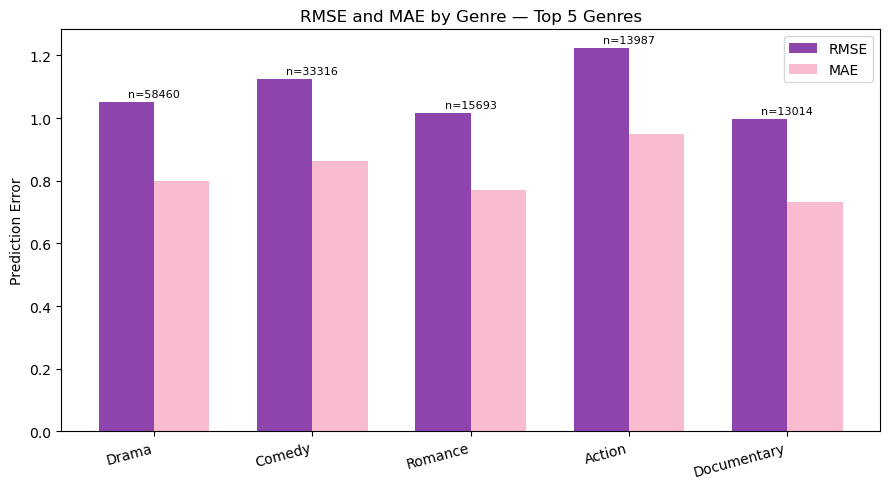

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(len(df_genre))
width = 0.35
ax.bar(positions - width / 2,df_genre["RMSE"],width,label="RMSE",color="#8E44AD")   

ax.bar(positions + width / 2,df_genre["MAE"],width,label="MAE",color="#F8BBD0")   
ax.set_xticks(positions)
ax.set_xticklabels(df_genre["genre"], rotation=15, ha="right")
ax.set_title("RMSE and MAE by Genre — Top 5 Genres")
ax.set_ylabel("Prediction Error")
ax.legend()

for i, row in df_genre.iterrows():
    ax.text(
        i,
        max(row["RMSE"], row["MAE"]) + 0.01,
        f'n={int(row["N"])}',
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# SECTION 6.1 SPLIT 2: BY DECADE

- Adding decade column from X to errors
- Calculate RMSE and MAE by decade
- Keep decades with enough movies for a meaningful comparison
- Sort decades chronologically
- Calculate the difference compared with overall model performance. Positive value = worse performance than the overall average. Negative value = better performance than the overall average
- Display the results table

In [42]:
errors["decade"] = X["decade"].values

df_decade = (
    errors
    .dropna(subset=["decade"])
    .groupby("decade")
    .agg(
        N=("sq_error", "count"),
        RMSE=("sq_error", lambda x: np.sqrt(x.mean())),
        MAE=("abs_error", "mean")
    )
    .reset_index()
)

df_decade = df_decade[df_decade["N"] >= 100].copy()

df_decade["decade_numeric"] = (
    df_decade["decade"]
    .str.replace("s", "", regex=False)
    .astype(int)
)

df_decade = (
    df_decade
    .sort_values("decade_numeric")
    .drop(columns="decade_numeric")
)

df_decade["RMSE_difference_%"] = (
    (df_decade["RMSE"] - overall_rmse) / overall_rmse * 100
)

df_decade["MAE_difference_%"] = (
    (df_decade["MAE"] - overall_mae) / overall_mae * 100
)

display(df_decade.round(3))

,decade,N,RMSE,MAE,RMSE_difference_%,MAE_difference_%
1,1910s,171,0.870,0.651,-22.029,-23.339
2,1920s,785,1.009,0.757,-9.574,-10.885
3,1930s,3121,0.812,0.599,-27.189,-29.419
4,1940s,3292,0.808,0.610,-27.565,-28.175
5,1950s,4602,0.885,0.675,-20.625,-20.519
6,1960s,6208,0.986,0.774,-11.561,-8.853
7,1970s,7969,1.015,0.797,-9.007,-6.134
8,1980s,9631,1.056,0.828,-5.311,-2.524
9,1990s,10213,1.068,0.828,-4.261,-2.516
10,2000s,17555,1.142,0.872,2.401,2.706


## Plot to visualize


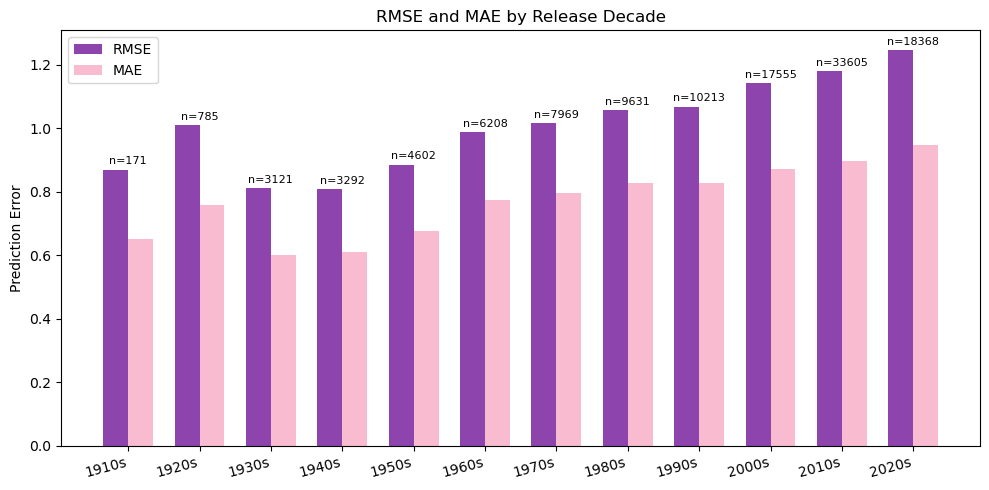

In [43]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(len(df_decade))
width = 0.35

ax.bar(positions - width / 2, df_decade["RMSE"], width,label="RMSE", color="#8E44AD")

ax.bar(positions + width / 2, df_decade["MAE"], width, label="MAE", color="#F8BBD0")

ax.set_xticks(positions)
ax.set_xticklabels(df_decade["decade"], rotation=15, ha="right")
ax.set_title("RMSE and MAE by Release Decade")
ax.set_ylabel("Prediction Error")
ax.legend()

for i, row in df_decade.reset_index(drop=True).iterrows():
    ax.text(
        i,
        max(row["RMSE"], row["MAE"]) + 0.01,
        f'n={int(row["N"])}',
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# SECTION 7  FEATURE IMPORTANCE: ELASTIC NET

* Get feature names after preprocessing
* Get Elastic Net coefficients
* Build a dataframe with one row per feature and its coefficient
* Calculate the absolute value of each coefficient to measure feature importance
* Identify whether each feature has a positive, negative or zero effect on the predicted rating
* Sort features by absolute coefficient value
* Display the 5 most important features


In [44]:
feature_names_elastic = (model_elastic.named_steps["preprocessor"].get_feature_names_out())

elastic_coefs = model_elastic.named_steps["model"].coef_

elastic_importance = pd.DataFrame({
    "feature": feature_names_elastic,
    "coefficient": elastic_coefs
})

elastic_importance["abs_coefficient"] = (
    elastic_importance["coefficient"].abs()
)

elastic_importance["direction"] = np.where(
    elastic_importance["coefficient"] > 0,
    "positive",
    np.where(
        elastic_importance["coefficient"] < 0,
        "negative",
        "zero"
    )
)


elastic_importance["feature"] = (elastic_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top5_elastic = (
    elastic_importance
    .sort_values("abs_coefficient", ascending=False)
    .head(5)
)

top5_elastic

,feature,coefficient,abs_coefficient,direction
9,genre_Documentary,0.385849,0.385849,positive
14,genre_Horror,-0.253180,0.253180,negative
0,runtimeMinutes,0.244845,0.244845,positive
7,genre_Drama,0.139495,0.139495,positive
11,genre_Action,-0.126652,0.126652,negative


# SECTION 7 — FEATURE IMPORTANCE: RANDOM FOREST

- Retrieve feature names after preprocessing
- Transform the dataset using the fitted preprocessor
- Convert the transformed matrix into a regular array if necessary
- Calculate permutation importance by shuffling each feature and measuring how much the RMSE worsens
- Generate Random Forest predictions on the transformed dataset
- Build a dataframe with one row per transformed feature and its importance score
- Remove technical prefixes from feature names for readability
- Estimate whether each feature is generally associated with higher or lower predicted ratings using correlation with predictions
- Sort features by permutation importance
- Display the 5 most important features

In [45]:
feature_names_rf = (model_rf.named_steps["preprocessor"].get_feature_names_out())

X_rf_transformed = (model_rf.named_steps["preprocessor"].transform(X))

if hasattr(X_rf_transformed, "toarray"):X_rf_transformed = X_rf_transformed.toarray()


perm_importance_rf = permutation_importance(model_rf.named_steps["model"],
                                            X_rf_transformed,
                                            y,
                                            n_repeats=5,
                                            random_state=42,
                                            scoring="neg_root_mean_squared_error",
                                            n_jobs=-1
                                        )


rf_predictions = (model_rf.named_steps["model"].predict(X_rf_transformed))


rf_importance = pd.DataFrame({"feature": feature_names_rf,"importance": perm_importance_rf.importances_mean})


rf_importance["feature"] = (rf_importance["feature"].str.replace("num__", "", regex=False)
                            .str.replace("cat__", "", regex=False))


rf_correlations = (pd.DataFrame(X_rf_transformed,columns=feature_names_rf).corrwith(pd.Series(rf_predictions)))

rf_importance["correlation_with_prediction"] = rf_correlations.values
rf_importance["estimated_direction"] = np.where(rf_importance["correlation_with_prediction"] > 0,"positive",
                                    np.where(rf_importance["correlation_with_prediction"] < 0,"negative",
                                        "no clear direction"))


top5_rf = (rf_importance.sort_values("importance", ascending=False).head(5))
top5_rf

,feature,importance,correlation_with_prediction,estimated_direction
0,runtimeMinutes,0.155883,0.288526,positive
9,genre_Documentary,0.110883,0.554233,positive
14,genre_Horror,0.075356,-0.513406,negative
7,genre_Drama,0.064951,0.211783,positive
6,age_x_country_known,0.056702,0.089805,positive


### Several genre-related features appear among the most important features in both models. This shows that genre has a strong influence on the predicted rating. However, the effect is not the same for every genre: for example, `genre_Documentary` and `genre_Drama` have a positive effect, while `genre_Horror` and `genre_Action` have a negative effect.


## Train and save the best model

In [46]:
best_model.fit(X, y)

joblib.dump(best_model, "model.pkl")

print(f"Saved model: {best_model_name}")

Saved model: Random Forest
